In [1]:
''' compare activity on occupied vs. empty checks and visits '''
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from scipy import stats
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from skimage import measure

import sys
sys.path.append("..//neural/")
import format_waveform_data, waveform_analysis
sys.path.append("..//utils/")
from helpers import nan_interp
from neural_analysis import tuning_curve_1d #, tuning_curve_2d
from load_matlab_data import loadmat_sbx

import scipy.io
import os
# import mat73

In [2]:
''' set paths '''
root_dir = "Z:/Isabel/data/"
bird_id = 'LMN88'
session_id = '260716'
# locker_root = f"{root_dir}hpc_implants/{bird_id}/{bird_id}_{session_id}/"
locker_root = f"{root_dir}lhy_implants/{bird_id}/{bird_id}_{session_id}/"

# to load waveforms and probe info
# local_root = "../data/antidromic_stim/" # local
ephys_id = "LMN88_260716_132924"
ks_dir = "kilosort4_bc/kilosort4/"
session_dir = f"{locker_root}/{ephys_id}/" # locker
# session_dir = f"{local_root}{bird_id}/" # local
ephys_dir = f"{session_dir}/"

# specify broken channels for this session
'''
AMB154_241119 - broken_channels = np.asarray([3, 23, 28, 29, 41, 48, 50, 61, 63])
RBY94_241129 - broken_channels = np.asarray([14, 22, 35, 42, 48])
SLV132_250303 - broken_channels = np.asarray([53, 56, 57, 63])
'''
broken_channels = np.asarray([])

# to load raw keypoints, model performance measures, behavior
pred_file = f'260717_posture_2stage_face.npy'
data_dir = f"{locker_root}behavior_data/"
pred_path = f"{data_dir}{pred_file}"
annotated_seed_file = "annotatedSeeds.mat"

# arena model
arena_folder = 'Z:/Isabel/arena/v0/arena_model/'
image_file = 'arena_model-01.png'

In [3]:
# set save folder
save_plots = False
save_dir = f"../figures/basic_neural_analysis/{bird_id}/"
if os.path.isdir(save_dir):
    print('save directory exists')
else:
    os.mkdir(save_dir)
save_folder = f"{save_dir}/{bird_id}_{session_id}/"
if os.path.isdir(save_folder):
    print('save folder exists')
else:
    os.mkdir(save_folder)
save_subfolder = f"{save_folder}seed_analysis/"
if os.path.isdir(save_subfolder):
    print('save sub-folder exists')
else:
    os.mkdir(save_subfolder)

save directory exists


In [4]:
''' probe info '''
sampling_rate = 30000
n_channels_shank = 32
A_shank = np.arange(n_channels_shank)
B_shank = np.arange(n_channels_shank) + n_channels_shank
A_shank = np.setdiff1d(A_shank, broken_channels)
B_shank = np.setdiff1d(B_shank, broken_channels)

In [5]:
''' load and format the waveform struct '''
waveform_struct = format_waveform_data.load_wf_data(session_dir, ks_dir=ks_dir)
wf_ids = waveform_struct['goodIDs']
mean_waveforms, wf_channels, _, ch_names = format_waveform_data.sort_wf_by_channel('', waveform_struct,
                                                                                   data_dir=ephys_dir,
                                                                                   return_ch_names=True)

Z:/Isabel/data/lhy_implants/LMN88/LMN88_260716//LMN88_260716_132924/kilosort4_bc/kilosort4/waveformStruct.mat
Z:/Isabel/data/lhy_implants/LMN88/LMN88_260716//LMN88_260716_132924//intan_info.mat


In [6]:
# filter out the bad channels and get the new channel index
all_ch = np.arange(mean_waveforms.shape[1])
good_idx = np.setdiff1d(all_ch, broken_channels)
mean_waveforms = mean_waveforms[:, good_idx]
ch_names = [ch_names[i] for i in good_idx]
wf_ch_idx = np.asarray([ch_names.index(ch) for ch in wf_channels])
n_cells = mean_waveforms.shape[0]

# get the cell IDs and raw spike times
good_clusters, spike_id, spike_samp_raw = format_waveform_data.get_spike_times(session_dir, ks_dir=ks_dir)
assert good_clusters.shape[0] == n_cells

In [7]:
# get the session average firing rate
avg_firing_rate = waveform_struct['meanRate']

In [8]:
''' cluster to get the excitatory index '''
fr = waveform_struct['meanRate']
width = np.zeros(n_cells)
asymm = np.zeros(n_cells)
for wf_idx in range(n_cells):
    best_ch = wf_ch_idx[wf_idx]
    width[wf_idx] = waveform_analysis.calc_spike_width(mean_waveforms[wf_idx, best_ch])
    asymm[wf_idx] = waveform_analysis.calc_amp_assym(mean_waveforms[wf_idx, best_ch])  
    
# get the log firing rate
log_fr = np.log10(fr)

# get the cluster indices - swap as needed so interneurons are clu2
clu1_idx, clu2_idx = waveform_analysis.clu_waveforms_kmeans(width, asymm, log_fr)

C:\Users\Isabel\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Isabel\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Isabel\miniconda3\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Isabel\miniconda3\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Isabel\miniconda3\Lib\subprocess.py", line 1540, in _execute_child
    hp, ht, pid, tid = _winapi

In [9]:
# for log scaling the FR axis
import matplotlib.ticker as mticker
def log_tick_formatter(val, pos=None):
    return f"$10^{{{val:g}}}$"

35/53 cells are putative excitatory neurons (66.0%)


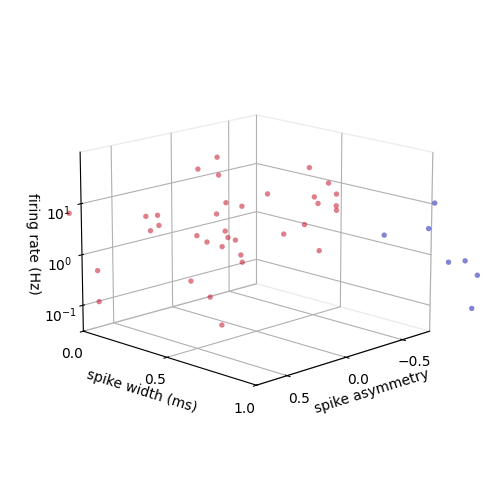

In [10]:
''' plot the waveform properties '''
fig = plt.figure(figsize=(8, 4))
ax = plt.axes([0, 0, .6, 1.2], projection='3d')

n_excite = np.sum(clu1_idx)
print(f'{n_excite}/{n_cells} cells are putative excitatory neurons ({np.round((n_excite/n_cells)*100, 1)}%)')

# all excitatory cells
ax.scatter(asymm[clu1_idx],
           width[clu1_idx],
           log_fr[clu1_idx],
           c='xkcd:scarlet',
           alpha=0.5, lw=0, s=15, zorder=0)

# all inhibitory cells
ax.scatter(asymm[clu2_idx],
           width[clu2_idx],
           log_fr[clu2_idx],
           c='xkcd:cobalt blue', 
           alpha=0.5, lw=0, s=15, zorder=0)

# labels
ax.set_xlabel('spike asymmetry')
ax.set_ylabel('spike width (ms)')
ax.set_zlabel('firing rate (Hz)')

# log scale the z-axis
ax.zaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.zaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# limits
ax.set_xlim([-0.75, 0.75])
ax.set_xticks([-0.5, 0, 0.5])
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.5, 1])

# background color
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('xkcd:grey')
ax.yaxis.pane.set_edgecolor('xkcd:grey')
ax.zaxis.pane.set_edgecolor('xkcd:grey')
ax.xaxis.pane.set_color('xkcd:light grey')
ax.yaxis.pane.set_color('xkcd:light grey')
ax.zaxis.pane.set_color('xkcd:light grey')

ax.view_init(azim=45, elev=15)
ax.set_box_aspect(aspect=None, zoom=0.8)
plt.show()

fig.savefig(f'{save_folder}waveform_props.png', 
                  dpi=600, bbox_inches='tight')

In [11]:
''' load and format the annotated seed struct '''
seed_struct = loadmat_sbx(f'{data_dir}{annotated_seed_file}')['annotatedSeeds']
count_data = seed_struct['countData']
print(seed_struct.keys())
print(count_data.keys())

Z:/Isabel/data/lhy_implants/LMN88/LMN88_260716/behavior_data/annotatedSeeds.mat
dict_keys(['countData', 'bk_height_seedDetect', 'smSeedWindow', 'gainThresh', 'loseThresh', 'minLoseDur', 'validFrames', 'seedIntTol', 'path', 'beakPos', 'smSeed', 'cacheLoc', 'seedTimes', 'nEvents', 'newCacheTimes', 'endCacheTimes', 'cacheNum', 'fromCache_site', 'fromCache_event', 'toCache_site', 'toCache_event', 'gainMat', 'loseMat', 'initImgs', 'preIms', 'postIms', 'flagInt', 'seedChanges', 'initSeedCounts', 'prePreds', 'postPreds'])
dict_keys(['newPerch', 'endPerch', 'perchNum', 'newSite', 'endSite', 'siteNum', 'newFeeder', 'endFeeder', 'feederNum', 'newWater', 'endWater', 'waterNum', 'newBeakPerch', 'endBeakPerch', 'beakPerchNum', 'params'])


In [12]:
''' classify caches/retrievals/checks '''
# data params
all_int_start = count_data['newSite']
all_int_end = count_data['endSite']
all_int_changes = np.sum(seed_struct['seedChanges'], axis=1)
n_interactions = all_int_start.shape[0]

# checks = no change
check_onsets = all_int_start[all_int_changes == 0]
check_offsets = all_int_end[all_int_changes == 0]
checks = all_int_changes==0

In [13]:
''' classify visits '''
# get all perch interactions
all_perch_start = count_data['newPerch']
all_perch_end = count_data['endPerch']
all_perch_idx = count_data['perchNum']
n_perches = all_perch_start.shape[0]

# eating times
eat_onsets = count_data['newBeakPerch']
eat_offsets = count_data['endBeakPerch']
all_non_visit_start = np.append(eat_onsets, all_int_start)

# exclude perches with eating and site interactions
visits = np.full(n_perches, 1).astype(bool)
for i, (ps, pe) in enumerate(zip(all_perch_start, all_perch_end)):
    start_idx = all_non_visit_start > ps
    end_idx = all_non_visit_start < pe
    if any(start_idx & end_idx):
        visits[i] = False        
visit_onsets = all_perch_start[visits]

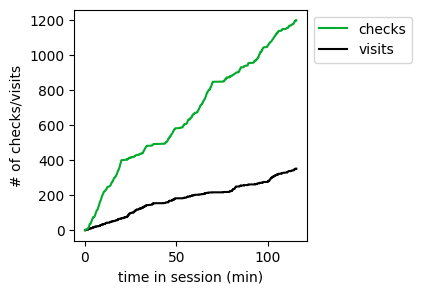

In [14]:
''' plot checks/visits over time in session '''
# feeder open periods in minutes
# feeder_t = np.asarray([10, 22, 54, 64, 124, 130]) # RBY94_241129
# feeder_t = np.asarray([10, 22, 67, 73, 118, 123]) # AMB154_241119
feeder_t = np.asarray([10, 20, 60, 72, 112, 122]) # SLV132_250310 10-22 min, 62-72 min, 112-122

# data/fig params
n_frames = checks.shape[0]
int_t_plot = all_int_end/50/60
visit_t_plot = all_perch_end/50/60
f, ax = plt.subplots(1, 1, figsize=(3, 3))

# checks and visits
ax.plot(int_t_plot, np.cumsum(checks), 
           label='checks', color='xkcd:kelly green', zorder=1)
ax.plot(visit_t_plot, np.cumsum(visits), 
           label='visits', color='k', zorder=0)
ax.set_xlabel('time in session (min)')
ax.set_ylabel('# of checks/visits')
ax.legend(bbox_to_anchor=(1, 1))

plt.show()
f.savefig(f'{save_folder}checks_visits.png', 
                  dpi=600, bbox_inches='tight')

In [15]:
''' get occupied vs. empty checks '''
n_checks = check_onsets.shape[0]

# for checks, intial seed count is known
seeds_in_sites = np.cumsum(seed_struct['seedChanges'], axis=0) + seed_struct['initSeedCounts']
interaction_site = count_data['siteNum'] - 1

# classify each check as occupied vs. empty
occupied_check = np.zeros(n_checks, dtype=bool)
check_idx = -1
for n_int in range(n_interactions):
    n_site = interaction_site[n_int]
    if checks[n_int]:
        check_idx += 1
    if seeds_in_sites[n_int, n_site] & checks[n_int]:
        occupied_check[check_idx] = True

In [16]:
''' get occupied vs. empty visits '''
n_visits = visit_onsets.shape[0]

# for visits, intial seed count is unknown
seeds_in_sites_visits = np.cumsum(seed_struct['seedChanges'], axis=0)
perch_site = count_data['perchNum']

# classify each visit as (known) occupied vs. empty/unknown
occupied_visit = np.zeros(n_visits, dtype=bool)
int_t = all_int_start[0]
int_idx = 0
visit_idx = -1
for n_perch, ps in enumerate(all_perch_start):
    if visits[n_perch]:
        n_site = perch_site[n_perch]
        visit_idx += 1
        if n_site < seeds_in_sites_visits.shape[1]: # exclude feeder perches
            if int_t < all_perch_start[n_perch]:
                int_idx += 1
                if int_idx < n_interactions:
                    int_t = all_int_start[int_idx]
                else:
                    int_idx -= 1
                    int_t = all_int_start[int_idx]
            if seeds_in_sites_visits[int_idx, n_site]:
                occupied_visit[visit_idx] = True

In [23]:
''' load the frame times '''
framet_raw = np.load(f'{data_dir}frame_times.npy')
framet_raw = np.squeeze(framet_raw)
dt = np.unique(np.round(np.diff(framet_raw), 4))
if dt.shape[0] > 1:
    print(f'warning irregular frame times!\nframe dt = {dt}')
else:
    dt = dt[0]
    
assert seed_struct['validFrames'].shape[0] == framet_raw.shape[0]

In [24]:
# align so that 0 is the video start time
start_t = framet_raw[0]
frame_t = framet_raw - start_t
spike_t = spike_samp_raw - start_t*sampling_rate
frame_samples = np.append(frame_t, frame_t[-1] + dt)*sampling_rate

# keep only spikes from within the session
spike_id = spike_id[(spike_t >= 0) & (spike_t <= frame_samples[-1])]
spike_t = spike_t[(spike_t >= 0) & (spike_t <= frame_samples[-1])]

n_frames = frame_t.shape[0]

In [25]:
''' spikes per frame and spike bool '''
spike_fr = np.zeros((n_cells, n_frames))
i = -1
for c_idx, cell in enumerate(good_clusters):
    i += 1
    spk_times = spike_t[spike_id==cell]       
    spike_fr[i], _ = np.histogram(spk_times, frame_samples)
spike_bool = spike_fr.astype(bool)

In [26]:
''' matrix spikes by matched number of empty/occupied checks '''
# number of occupied vs. empty checks
n_occupied_checks = np.sum(occupied_check)
n_empty_checks = n_checks - n_occupied_checks
n_checks_matched = np.min([n_occupied_checks, n_empty_checks])

# time window
t_window = 2 # seconds
t_points = np.arange(-t_window//2, t_window//2 + dt, dt)
n_t_pts = t_points.shape[0]
fr_halfwidth = n_t_pts//2

# get occupied vs. empty idx (downsample to match n)
occupied_idx = np.where(occupied_check)[0]
empty_idx = np.setdiff1d(np.arange(n_checks), occupied_idx)
occupied_check_idx = np.sort(np.random.choice(occupied_idx, 
                             size=n_checks_matched, replace=False))
empty_check_idx = np.sort(np.random.choice(empty_idx, 
                             size=n_checks_matched, replace=False))

n_checks_plotted = n_checks_matched*2

# matrix of spike times by check
check_on_mat = np.zeros((n_cells, n_checks_matched*2, n_t_pts), dtype=bool)
for c_idx in range(n_cells):
    spk_times = spike_bool[c_idx]
    
    # occupied checks
    for i, occ_idx in enumerate(occupied_check_idx):  
        start_idx = (check_onsets[occ_idx] - fr_halfwidth).astype(int)
        end_idx = (check_onsets[occ_idx] + fr_halfwidth + 1).astype(int)
        check_on_mat[c_idx, i] = spk_times[start_idx:end_idx]
    
    # empty checks
    j = n_checks_matched - 1
    for empt_idx in empty_check_idx:
        j += 1
        start_idx = (check_onsets[empt_idx] - fr_halfwidth).astype(int)
        end_idx = (check_onsets[empt_idx] + fr_halfwidth + 1).astype(int)
        check_on_mat[c_idx, j] = spk_times[start_idx:end_idx]

In [38]:
''' matrix spikes by matched number of empty/occupied checks '''
# number of occupied vs. empty checks
n_occupied_checks = np.sum(occupied_check)
n_empty_checks = n_checks - n_occupied_checks
n_checks_matched = np.min([n_occupied_checks, n_empty_checks])

# time window
t_window = 2 # seconds
t_points = np.arange(-t_window//2, t_window//2 + dt, dt)
n_t_pts = t_points.shape[0]
fr_halfwidth = n_t_pts//2

# get occupied vs. empty idx (don't downsample)
occupied_idx = np.where(occupied_check)[0]
empty_idx = np.setdiff1d(np.arange(n_checks), occupied_idx)
occupied_check_idx = np.sort(np.random.choice(occupied_idx, 
                             size=n_occupied_checks, replace=False))
empty_check_idx = np.sort(np.random.choice(empty_idx, 
                             size=np.min([n_empty_checks, 100]), replace=False))

# matrix of spike times by check
n_checks_plotted = n_occupied_checks + np.min([n_empty_checks, 100])
check_on_mat = np.zeros((n_cells, n_checks_plotted, n_t_pts), dtype=bool)
for c_idx in range(n_cells):
    spk_times = spike_bool[c_idx]
    
    # occupied checks
    for i, occ_idx in enumerate(occupied_check_idx):  
        start_idx = (check_onsets[occ_idx] - fr_halfwidth).astype(int)
        end_idx = (check_onsets[occ_idx] + fr_halfwidth + 1).astype(int)
        check_on_mat[c_idx, i] = spk_times[start_idx:end_idx]
    
    # empty checks
    j = n_occupied_checks - 1
    for empt_idx in empty_check_idx:
        j += 1
        start_idx = (check_onsets[empt_idx] - fr_halfwidth).astype(int)
        end_idx = (check_onsets[empt_idx] + fr_halfwidth + 1).astype(int)
        check_on_mat[c_idx, j] = spk_times[start_idx:end_idx]

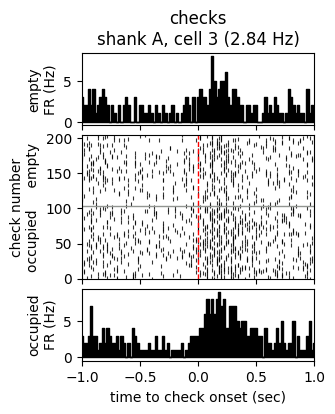

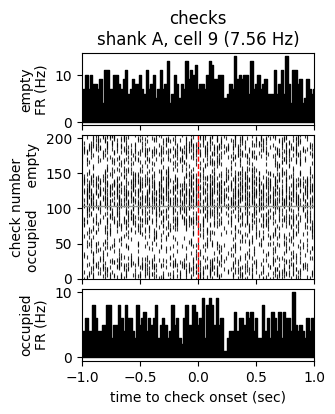

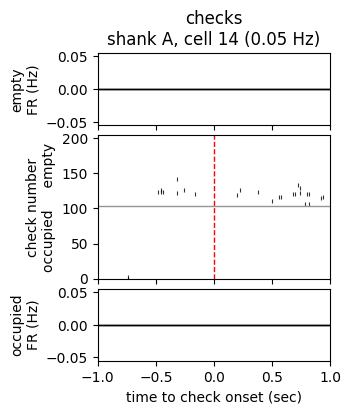

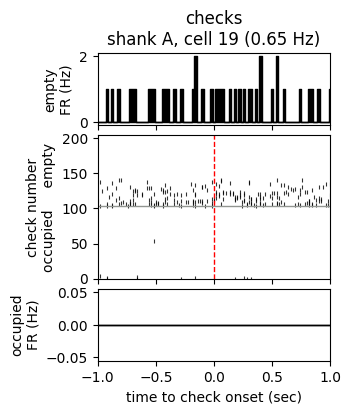

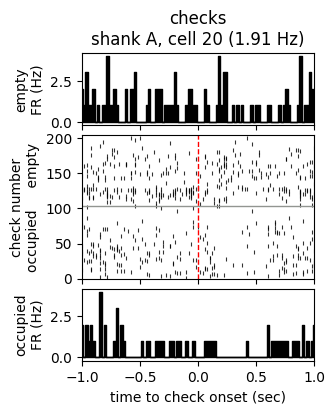

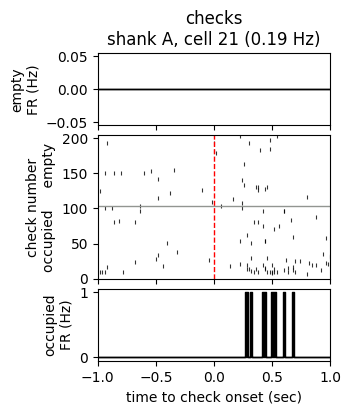

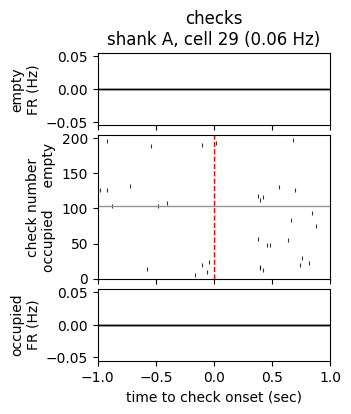

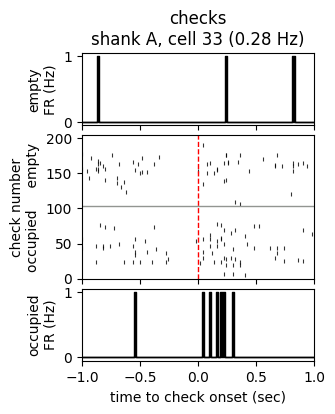

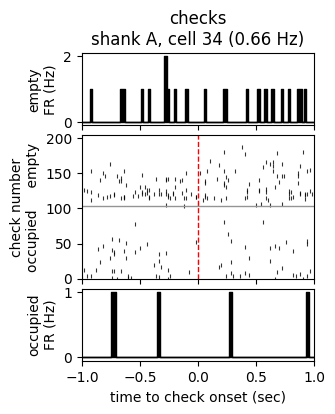

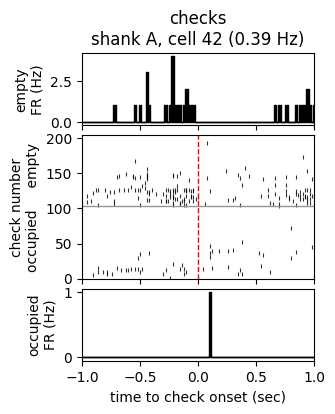

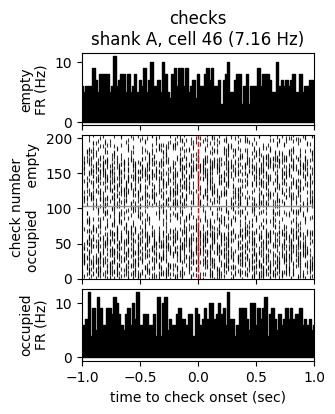

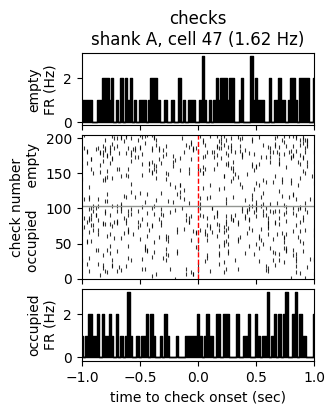

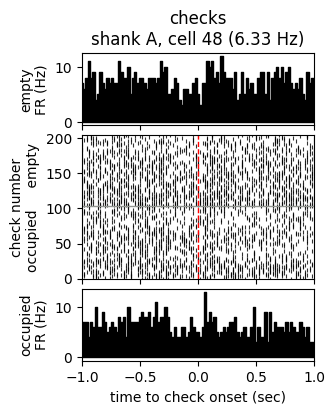

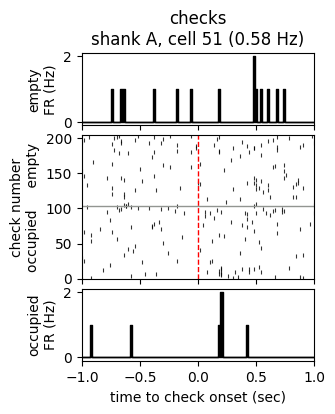

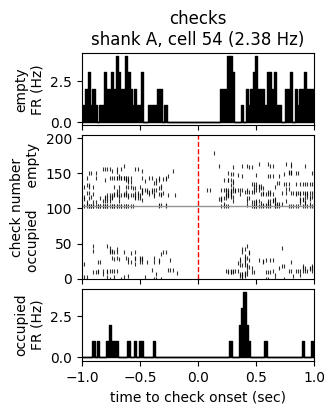

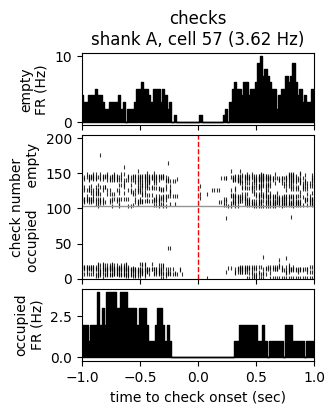

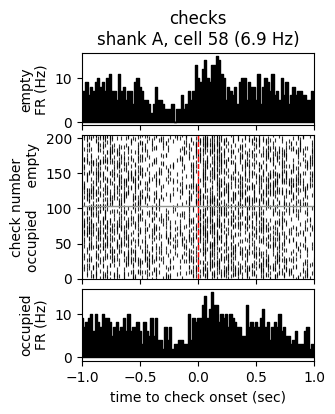

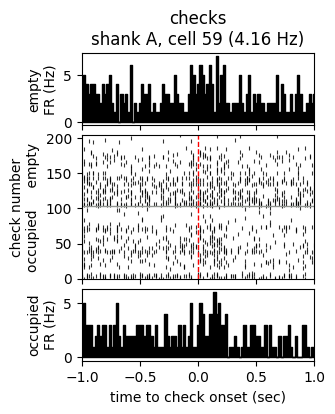

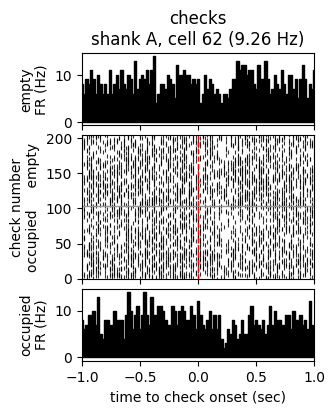

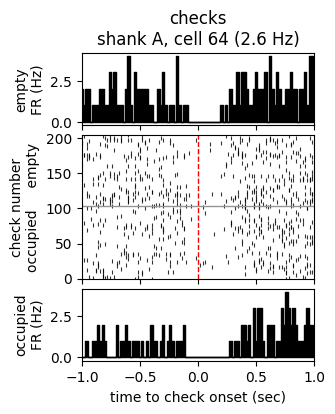

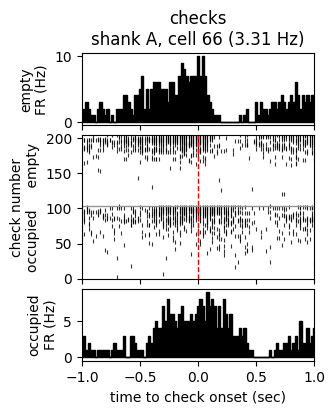

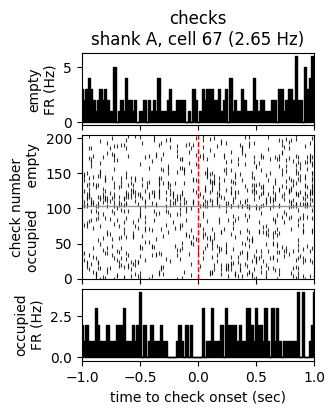

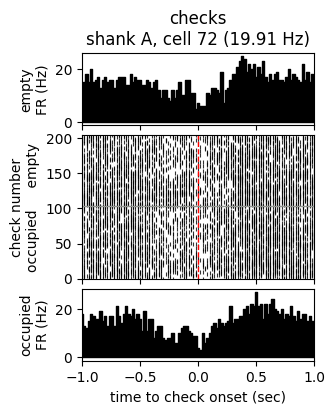

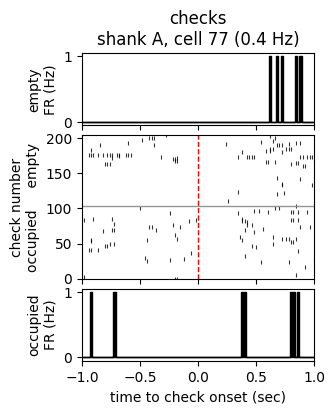

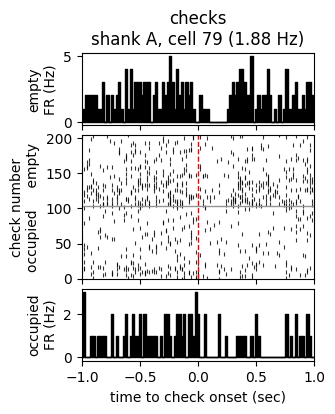

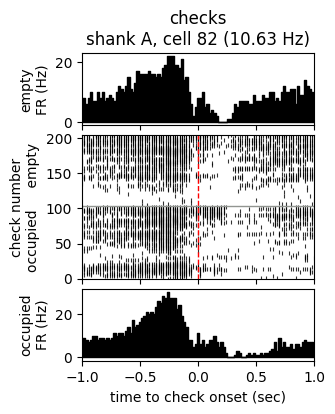

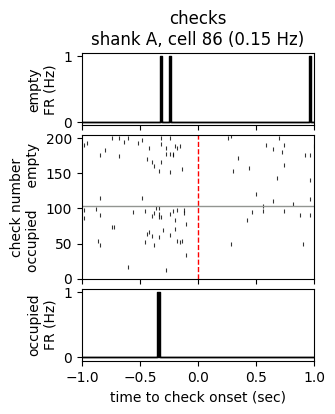

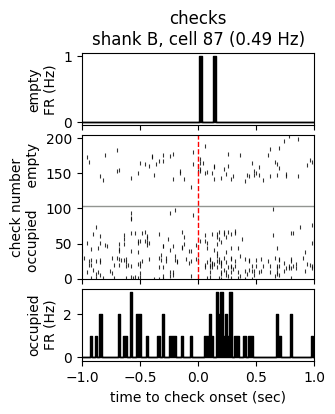

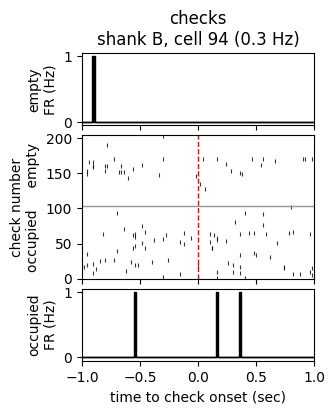

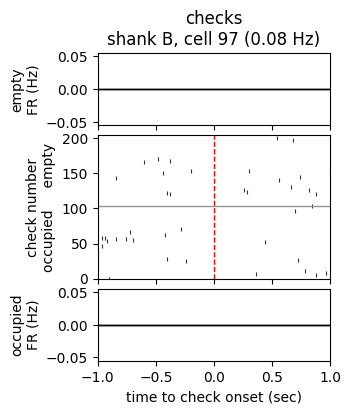

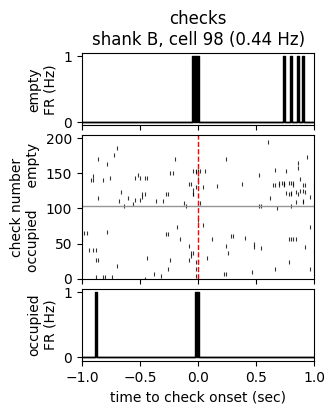

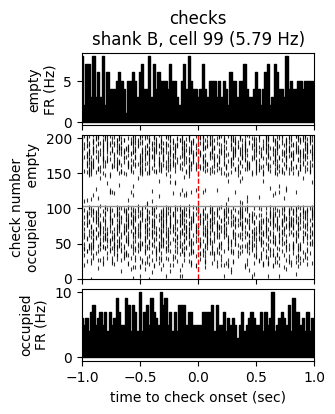

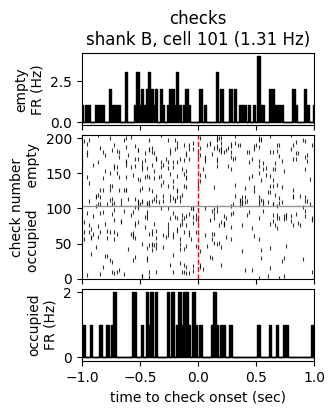

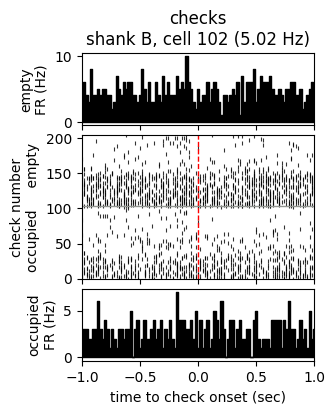

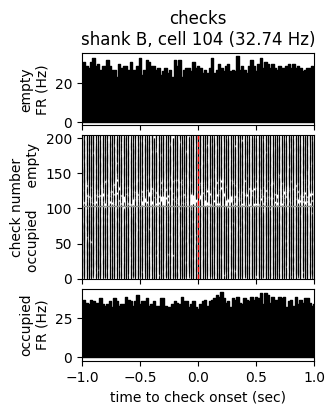

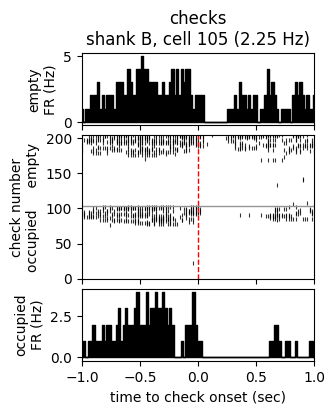

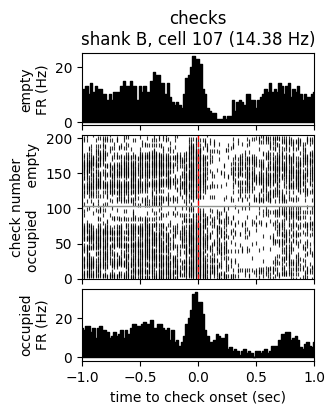

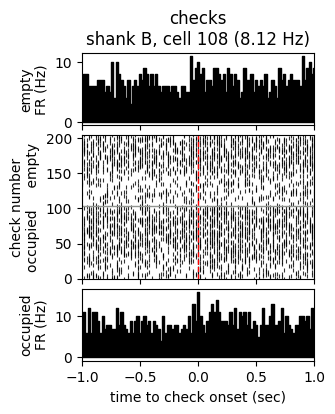

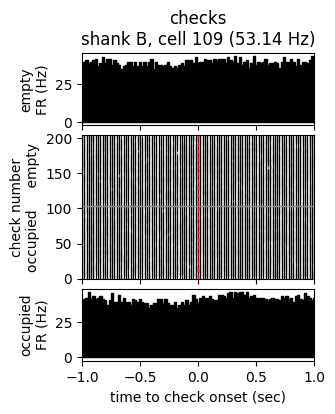

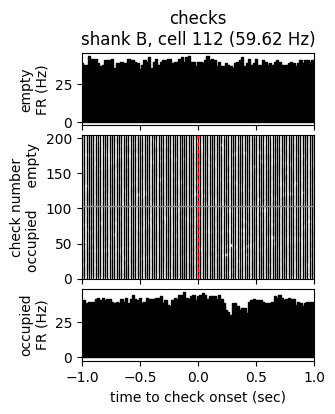

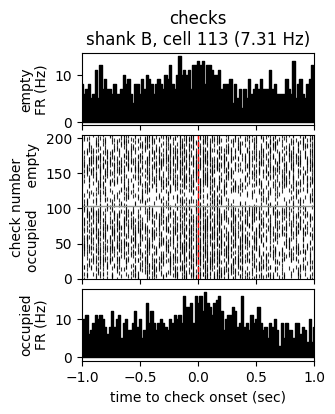

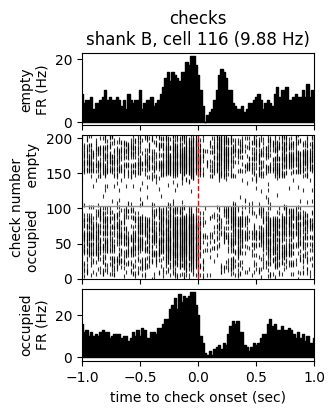

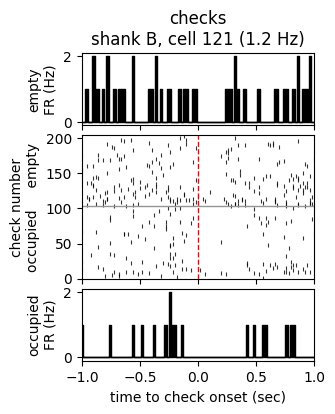

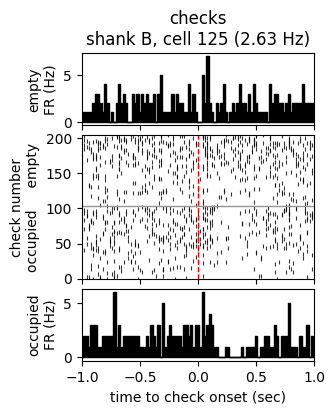

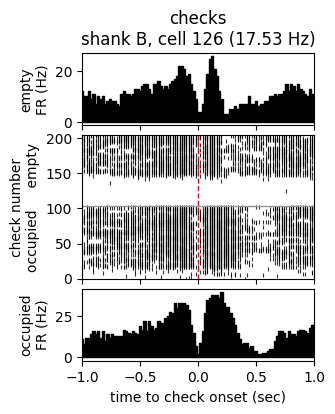

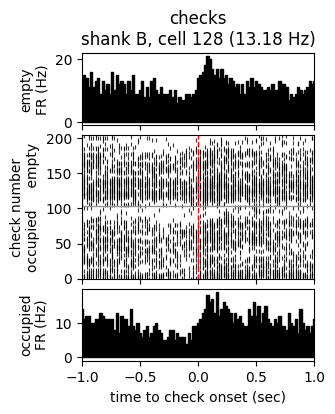

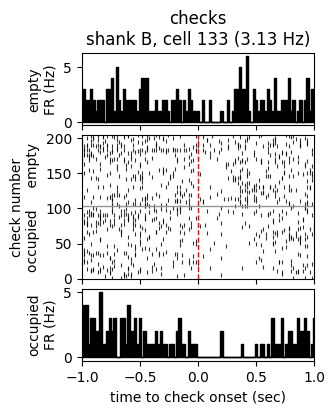

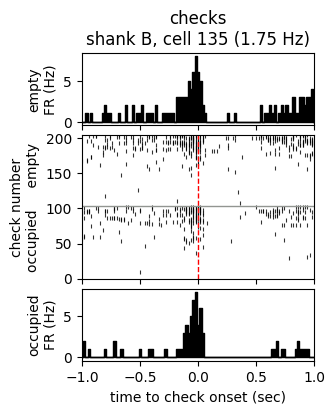

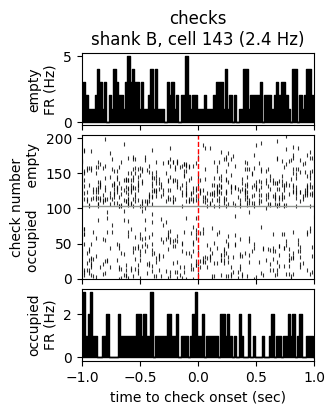

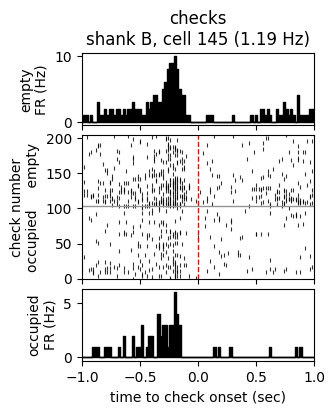

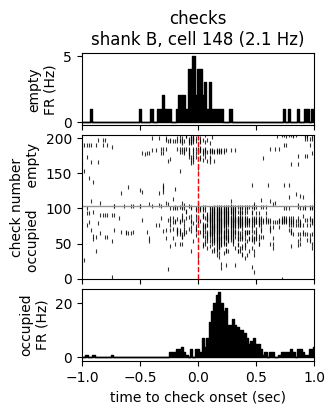

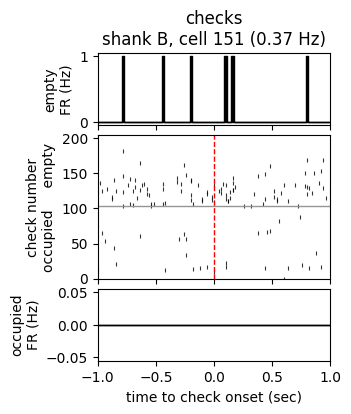

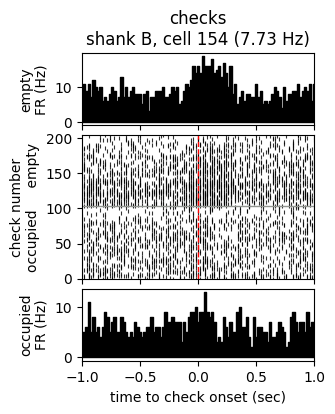

In [28]:
''' plot raster spikes by check - empty vs. occupied '''
# data params
avg_fr_session = np.round(avg_firing_rate, 2)

# psth check (occupied) vs. check (empty)
avg_fr_check_occ = np.mean(check_on_mat[:, :n_occupied_checks], axis=1)//dt
avg_fr_check_empt = np.mean(check_on_mat[:, n_occupied_checks:], axis=1)//dt

# fig params
occ_empt_lw = 1
on_lw = 1
spk_s = 10

for c_idx, cell_id in enumerate(good_clusters):
    ch = wf_ch_idx[c_idx]
    f, ax = plt.subplots(3, 1, figsize=(3, 4),
                         gridspec_kw=dict(height_ratios=[1, 2, 1],
                                          hspace=0.1))

    # plot raster aligned to check onsets
    for check_idx in range(n_checks_plotted):
        spk_idx = check_on_mat[c_idx, check_idx]
        spk_t = t_points[spk_idx]
        ax[1].scatter(spk_t, np.full(spk_t.shape[0], check_idx),
                      color='k', marker='|',
                      lw=0.8, s=spk_s, alpha=.8)
        
    # plot the average firing rate for occupied vs. empty
    ax[2].fill_between(t_points, avg_fr_check_occ[c_idx],
                          step="mid", color="k")
    ax[0].fill_between(t_points, avg_fr_check_empt[c_idx],
                          step="mid", color="k")

    # label onset and divide occupied vs. empty
    ax[1].vlines(0, 0, n_checks_plotted,
                 colors='r', linestyles='dashed', lw=on_lw)
    ax[1].hlines(n_occupied_checks, t_points[0], t_points[-1],
                 colors='xkcd:gray', linestyles='solid', lw=occ_empt_lw)
    
    # limits and labels
    ax[1].set_xlim(t_points[0], t_points[-1])
    ax[1].set_ylim(-0.5, n_checks_plotted - 0.5)
    ax[0].set_xlim(t_points[0], t_points[-1])
    ax[2].set_xlim(t_points[0], t_points[-1])

    ax[2].set_xticks(np.arange(-t_window//2, t_window//2 + 0.5, 0.5))
    ax[2].set_xlabel('time to check onset (sec)')
    ax[0].set_xticks(np.arange(-t_window//2, t_window//2 + 0.5, 0.5))
    ax[1].set_xticks(np.arange(-t_window//2, t_window//2 + 0.5, 0.5))
    ax[0].tick_params(labelbottom=False)
    ax[1].tick_params(labelbottom=False)
    
    if ch in A_shank:
        ax[0].set_title(f'checks\nshank A, cell {cell_id} ({avg_fr_session[c_idx]} Hz)')
    else: 
        ax[0].set_title(f'checks\nshank B, cell {cell_id} ({avg_fr_session[c_idx]} Hz)')
    ax[1].set_ylabel('check number\noccupied     empty')
    ax[0].set_ylabel('empty\nFR (Hz)')
    ax[2].set_ylabel('occupied\nFR (Hz)')
    
    plt.show()
    f.savefig(f'{save_subfolder}/checks_cell{cell_id}.png', 
                  dpi=600, bbox_inches='tight')

In [29]:
''' matrix spikes by matched number of empty/occupied visits '''
# time window
t_window = 8 # seconds
t_points = np.arange(-t_window//2, t_window//2 + dt, dt)
n_t_pts = t_points.shape[0]
fr_halfwidth = n_t_pts//2

# get occupied vs. empty idx (filter out ends)
occupied_idx = np.where(occupied_visit)[0]
empty_idx = np.setdiff1d(np.arange(n_visits), occupied_idx)
occupied_idx = occupied_idx[visit_onsets[occupied_idx] > fr_halfwidth]
occupied_idx = occupied_idx[visit_onsets[occupied_idx] < n_frames - fr_halfwidth]
empty_idx = empty_idx[visit_onsets[empty_idx] > fr_halfwidth]
empty_idx = empty_idx[visit_onsets[empty_idx] < n_frames - fr_halfwidth]

# number of occupied vs. empty visits
n_visits_max = 100 # maximum number of each type to plot
n_occupied_visits = occupied_idx.shape[0]
n_empty_visits = empty_idx.shape[0]
n_visits_matched = np.min([n_occupied_visits, n_empty_visits, n_visits_max])

# downsample to match
occupied_visit_idx = np.sort(np.random.choice(occupied_idx, 
                             size=n_visits_matched, replace=False))
empty_visit_idx = np.sort(np.random.choice(empty_idx, 
                             size=n_visits_matched, replace=False))
n_visits_plotted = n_visits_matched*2

# matrix of spike times by check
visit_on_mat = np.zeros((n_cells, n_visits_matched*2, n_t_pts), dtype=bool)
for c_idx in range(n_cells):
    spk_times = spike_bool[c_idx]
    
    # occupied visits
    for i, occ_idx in enumerate(occupied_visit_idx):  
        start_idx = (visit_onsets[occ_idx] - fr_halfwidth).astype(int)
        end_idx = (visit_onsets[occ_idx] + fr_halfwidth + 1).astype(int)
        visit_on_mat[c_idx, i] = spk_times[start_idx:end_idx]
    
    # empty visits
    j = n_visits_matched - 1
    for empt_idx in empty_visit_idx:
        j += 1
        start_idx = (visit_onsets[empt_idx] - fr_halfwidth).astype(int)
        end_idx = (visit_onsets[empt_idx] + fr_halfwidth + 1).astype(int)
        visit_on_mat[c_idx, j] = spk_times[start_idx:end_idx]

In [30]:
n_visits_plotted = n_visits_matched*2


In [40]:
''' matrix spikes by matched number of empty/occupied visits '''
# time window
t_window = 8 # seconds
t_points = np.arange(-t_window//2, t_window//2 + dt, dt)
n_t_pts = t_points.shape[0]
fr_halfwidth = n_t_pts//2

# get occupied vs. empty idx (filter out ends)
occupied_idx = np.where(occupied_visit)[0]
empty_idx = np.setdiff1d(np.arange(n_visits), occupied_idx)
occupied_idx = occupied_idx[visit_onsets[occupied_idx] > fr_halfwidth]
occupied_idx = occupied_idx[visit_onsets[occupied_idx] < n_frames - fr_halfwidth]
empty_idx = empty_idx[visit_onsets[empty_idx] > fr_halfwidth]
empty_idx = empty_idx[visit_onsets[empty_idx] < n_frames - fr_halfwidth]

# number of occupied vs. empty visits
n_visits_max = 100 # maximum number of each type to plot
n_occupied_visits = occupied_idx.shape[0]
n_empty_visits = empty_idx.shape[0]
n_visits_matched = np.min([n_occupied_visits, n_empty_visits, n_visits_max])

# don't downsample to match
occupied_visit_idx = np.sort(np.random.choice(occupied_idx, 
                             size=n_occupied_visits, replace=False))
empty_visit_idx = np.sort(np.random.choice(empty_idx, 
                             size=np.min([n_empty_visits, n_visits_max]), replace=False))
n_visits_plotted = n_occupied_visits + np.min([n_empty_visits, n_visits_max])

# matrix of spike times by check
visit_on_mat = np.zeros((n_cells, n_visits_plotted, n_t_pts), dtype=bool)
for c_idx in range(n_cells):
    spk_times = spike_bool[c_idx]
    
    # occupied visits
    for i, occ_idx in enumerate(occupied_visit_idx):  
        start_idx = (visit_onsets[occ_idx] - fr_halfwidth).astype(int)
        end_idx = (visit_onsets[occ_idx] + fr_halfwidth + 1).astype(int)
        visit_on_mat[c_idx, i] = spk_times[start_idx:end_idx]
    
    # empty visits
    j = n_occupied_visits - 1
    for empt_idx in empty_visit_idx:
        j += 1
        start_idx = (visit_onsets[empt_idx] - fr_halfwidth).astype(int)
        end_idx = (visit_onsets[empt_idx] + fr_halfwidth + 1).astype(int)
        visit_on_mat[c_idx, j] = spk_times[start_idx:end_idx]

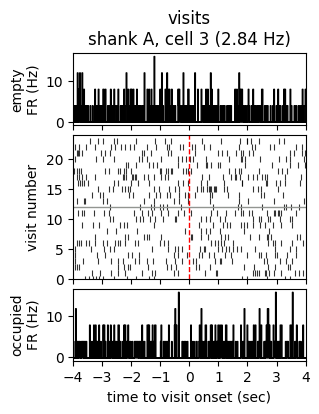

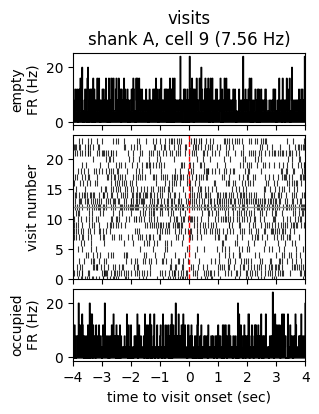

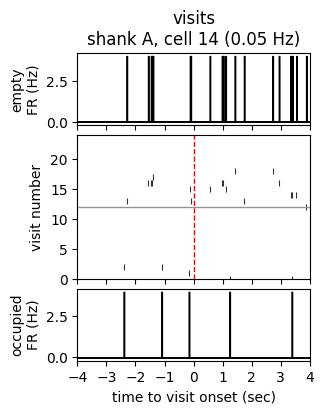

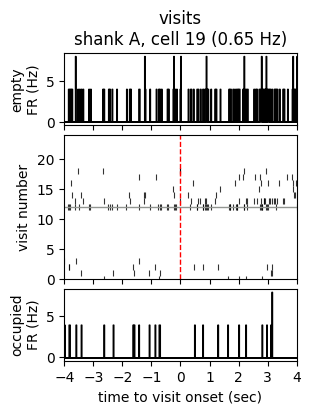

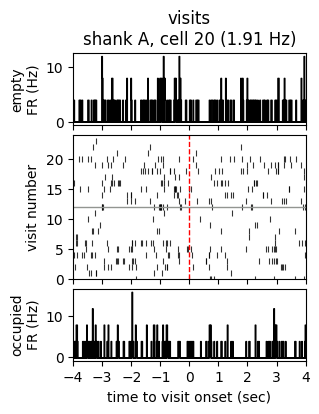

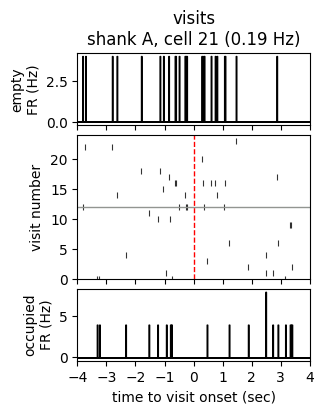

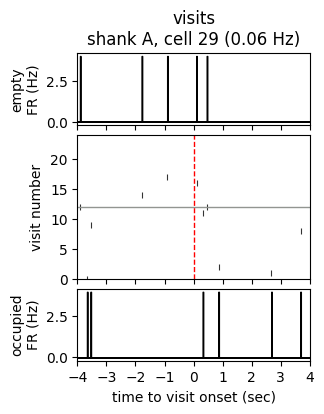

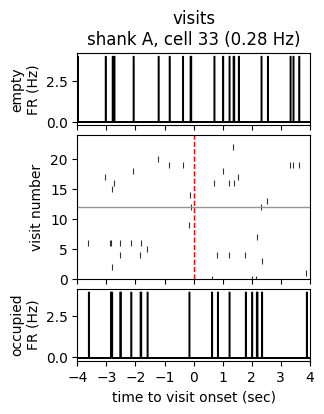

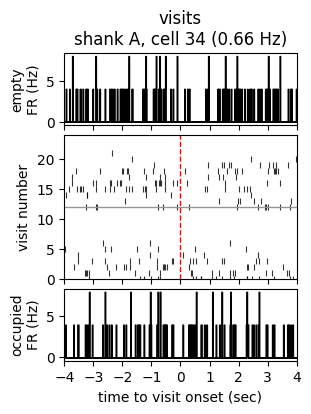

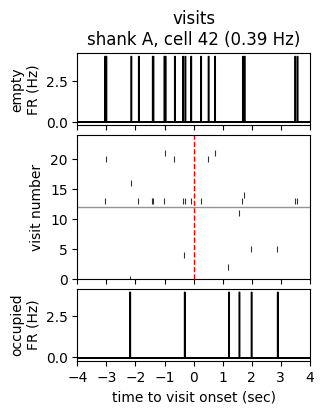

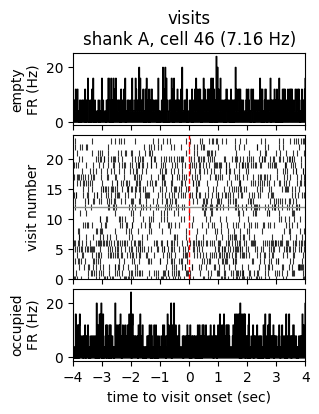

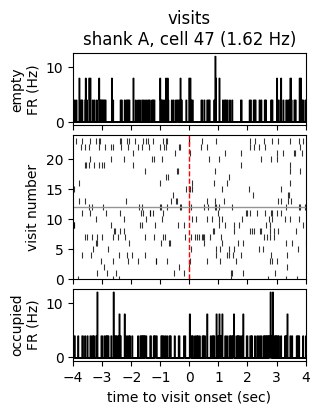

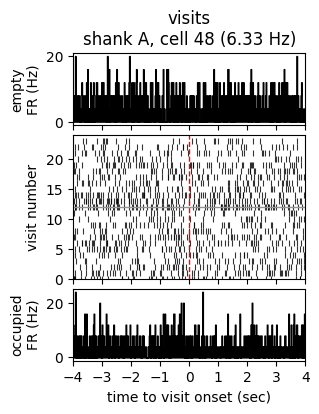

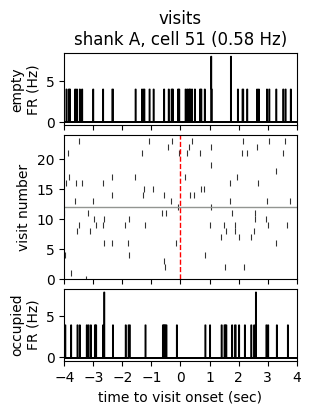

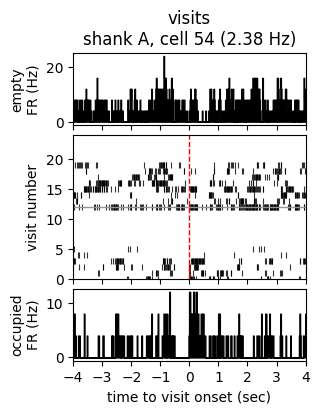

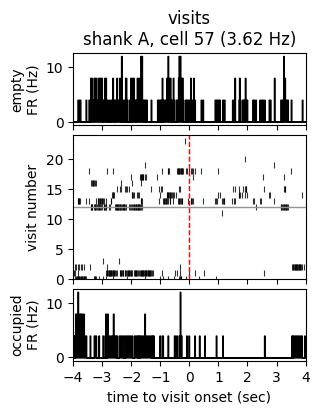

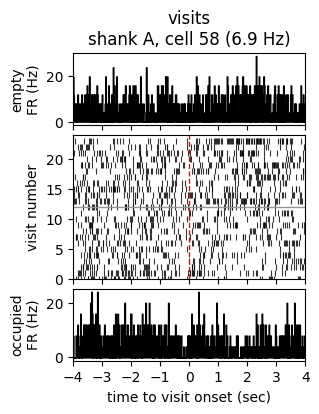

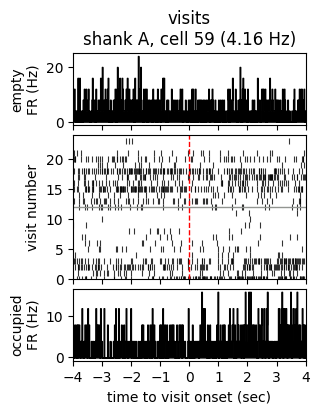

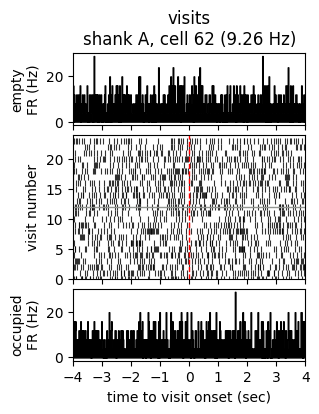

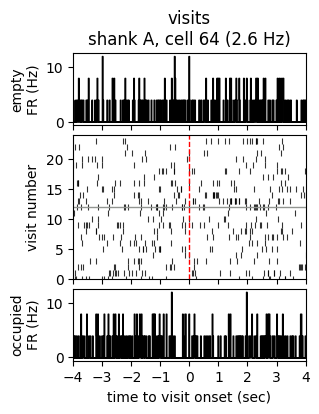

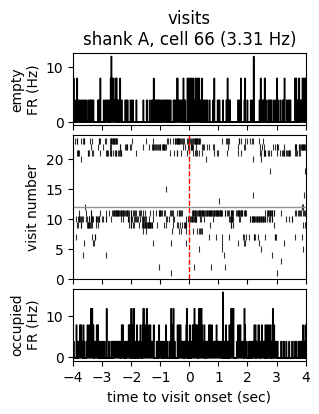

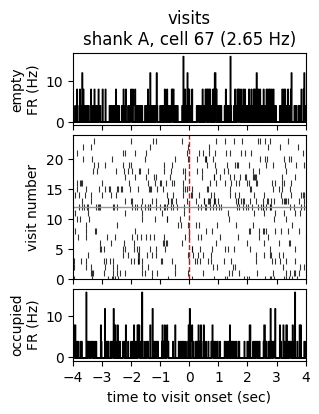

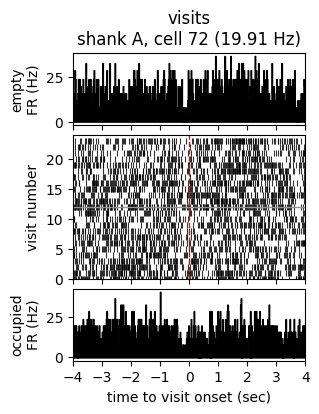

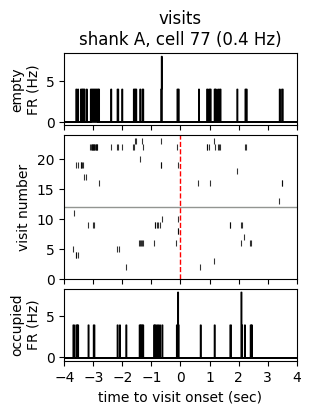

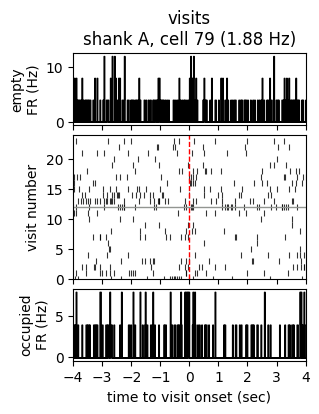

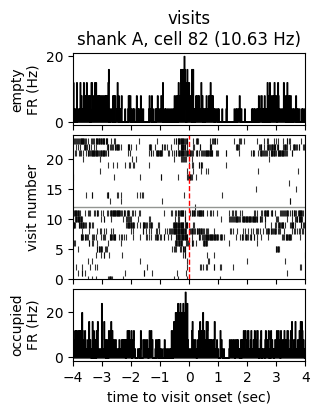

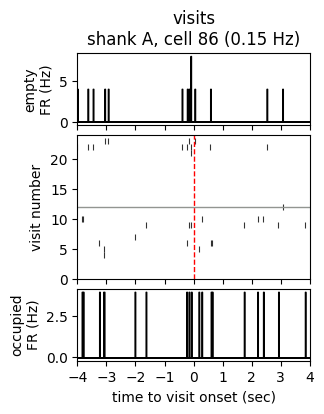

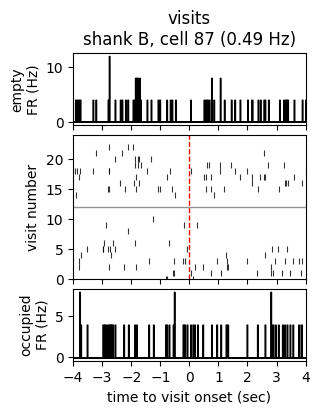

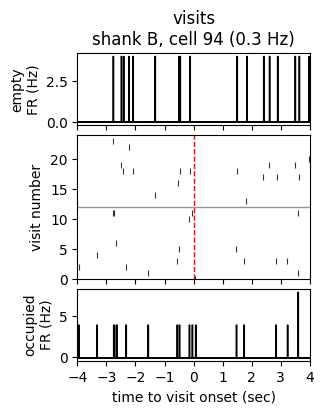

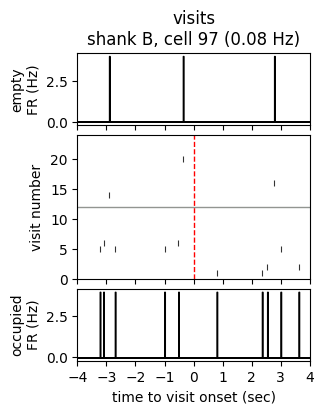

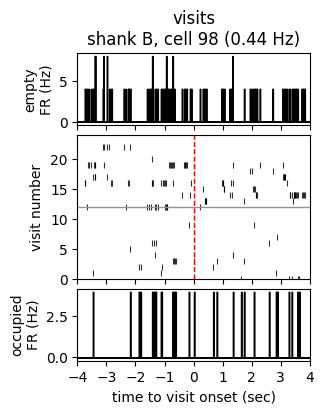

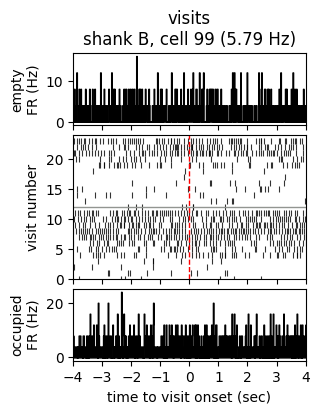

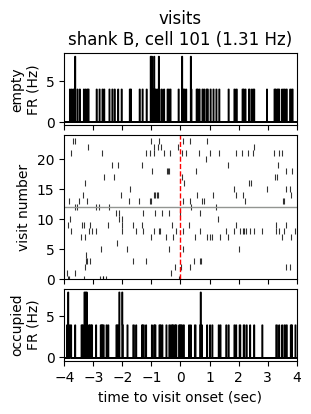

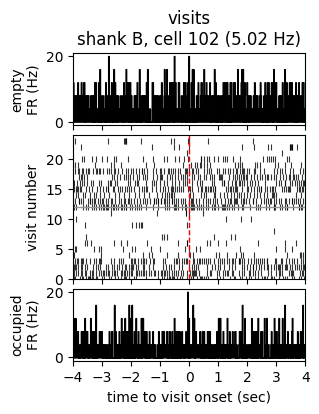

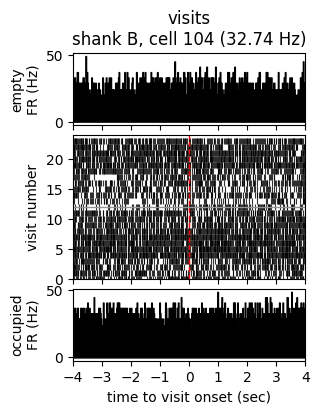

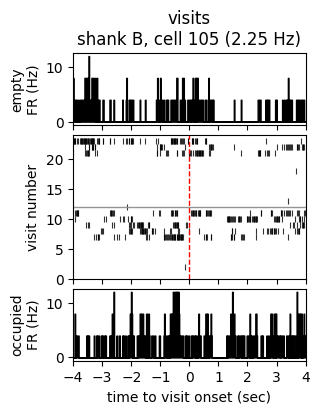

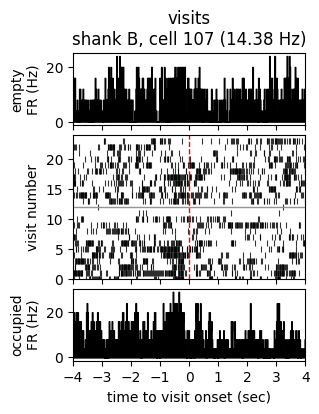

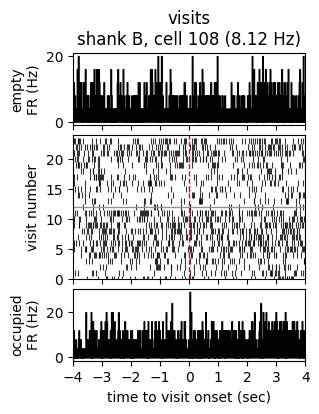

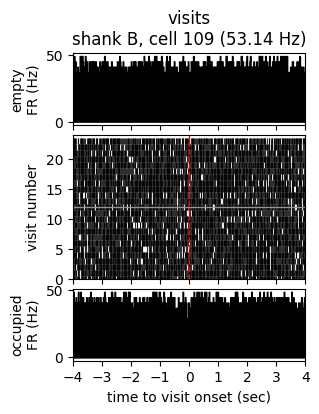

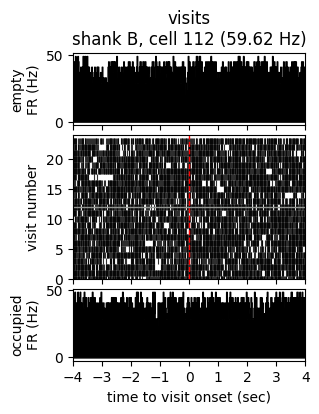

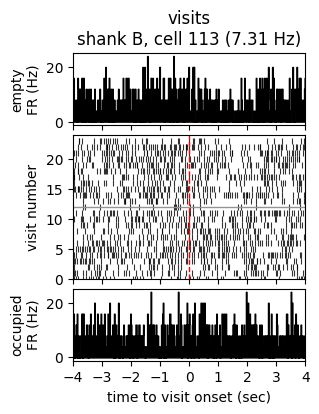

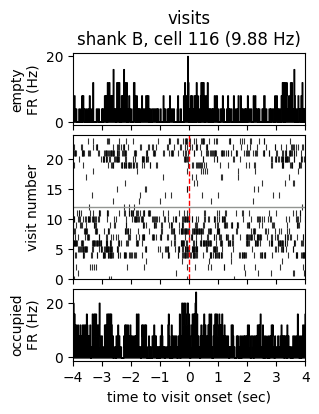

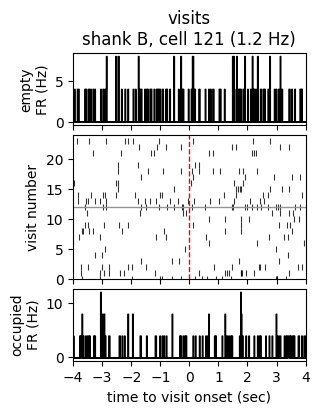

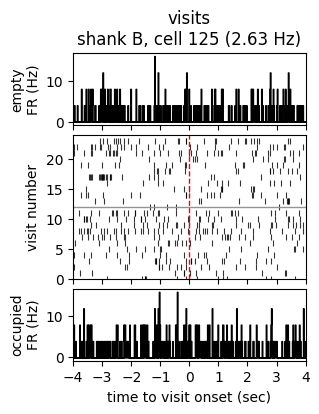

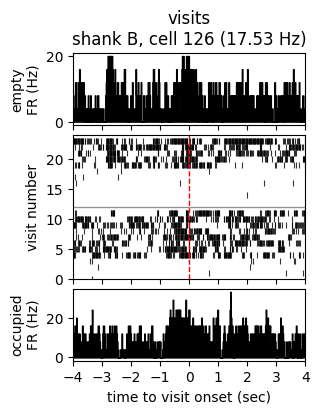

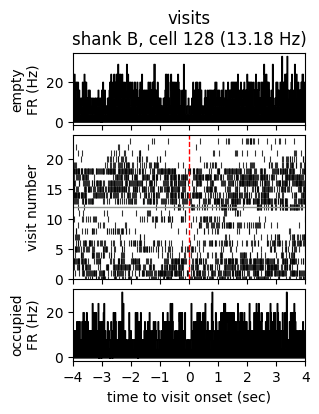

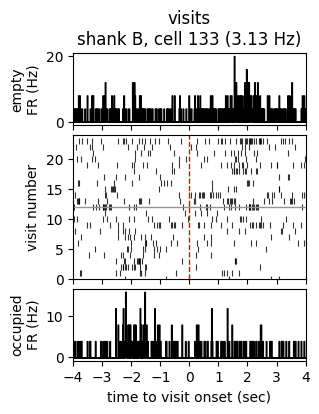

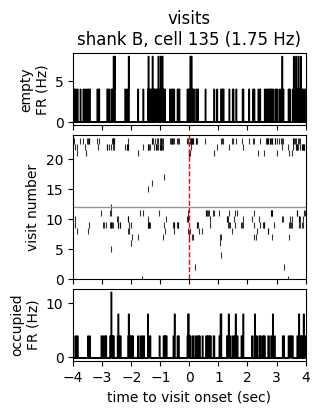

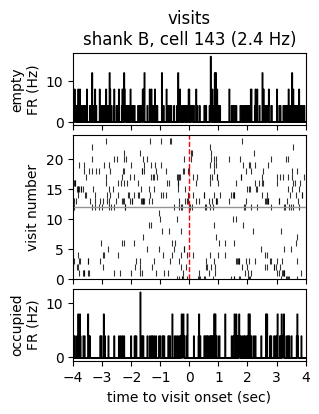

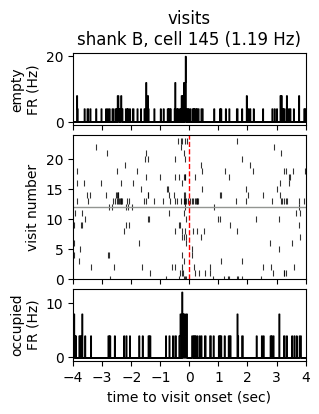

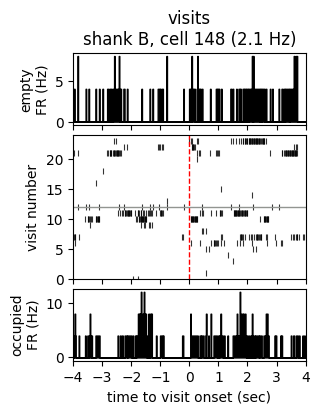

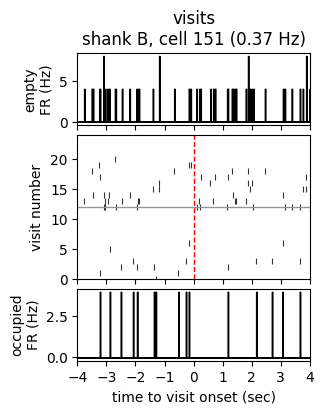

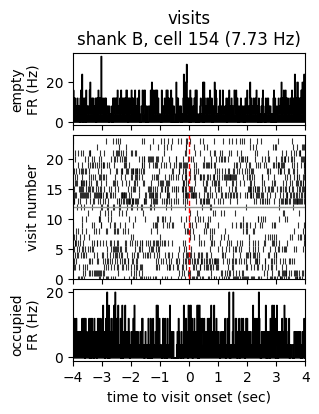

In [34]:
''' plot raster spikes by visit - empty vs. occupied '''
avg_fr_session = np.round(avg_firing_rate, 2)

# psth visit (occupied) vs. visit (empty)
avg_fr_visit_occ = np.mean(visit_on_mat[:, :n_occupied_visits], axis=1)//dt
avg_fr_visit_empt = np.mean(visit_on_mat[:, n_occupied_visits:], axis=1)//dt

# fig params
occ_empt_lw = 1
on_lw = 1
spk_s = 15
t_int = 1
save_fig = True

# cells to plot
cell_indices = good_clusters
# cell_indices = np.asarray([71, 314]) # selected cell ids

for cell_id in cell_indices:
    c_idx = np.where(good_clusters==cell_id)[0][0]
    ch = wf_ch_idx[c_idx]
    f, ax = plt.subplots(3, 1, figsize=(3, 4),
                         gridspec_kw=dict(height_ratios=[1, 2, 1],
                                          hspace=0.1))

    # plot raster aligned to visit onsets
    for visit_idx in range(n_visits_plotted):
        spk_idx = visit_on_mat[c_idx, visit_idx]
        spk_t = t_points[spk_idx]
        ax[1].scatter(spk_t, np.full(spk_t.shape[0], visit_idx),
                      color='k', marker='|',
                      lw=0.8, s=spk_s, alpha=.8)

    # plot the average firing rate for occupied vs. empty
    ax[2].fill_between(t_points, avg_fr_visit_occ[c_idx],
                          step="mid", color="k")
    ax[0].fill_between(t_points, avg_fr_visit_empt[c_idx],
                          step="mid", color="k")

    # label onset and divide occupied vs. empty
    ax[1].vlines(0, 0, n_visits_plotted,
                 colors='r', linestyles='dashed', lw=on_lw)
    ax[1].hlines(n_occupied_visits, t_points[0], t_points[-1],
                 colors='xkcd:gray', linestyles='solid', lw=occ_empt_lw)

    # limits and labels
    ax[1].set_xlim(t_points[0], t_points[-1])
    ax[1].set_ylim(0, n_visits_plotted)
    ax[0].set_xlim(t_points[0], t_points[-1])
    ax[2].set_xlim(t_points[0], t_points[-1])

    ax[2].set_xticks(np.arange(-t_window//2, t_window//2 + 0.5, t_int))
    ax[2].set_xlabel('time to visit onset (sec)')
    ax[0].set_xticks(np.arange(-t_window//2, t_window//2 + 0.5, t_int))
    ax[1].set_xticks(np.arange(-t_window//2, t_window//2 + 0.5, t_int))
    ax[0].tick_params(labelbottom=False)
    ax[1].tick_params(labelbottom=False)

    if ch in A_shank:
        ax[0].set_title(f'visits\nshank A, cell {cell_id} ({avg_fr_session[c_idx]} Hz)')
    else: 
        ax[0].set_title(f'visits\nshank B, cell {cell_id} ({avg_fr_session[c_idx]} Hz)')
    ax[1].set_ylabel('visit number')
    ax[0].set_ylabel('empty\nFR (Hz)')
    ax[2].set_ylabel('occupied\nFR (Hz)')

    plt.show()
    if save_fig:
        f.savefig(f'{save_subfolder}/visits_cell{cell_id}.png', 
                      dpi=600, bbox_inches='tight')